In [1]:
import numpy as np
from scipy.signal import butter, filtfilt,iirnotch
from scipy.signal import firwin,lfilter,kaiserord
from scipy.signal import spectrogram,freqz
import matplotlib.pyplot as plt
import wfdb  # reads MIT-BIH PhysioNet format
import time

In [2]:
# Load record 100 from MIT-BIH Arrhythmia Database
# wfdb downloads it automatically from PhysioNet if not cached
audio='100'
record =wfdb.rdrecord(audio,sampfrom=0,sampto=3600,pn_dir='mitdb')

In [3]:
# Extract the first channel (MLII lead)
ecg_signal = record.p_signal[:,0]
fs=record.fs  #Sampling frequency 

print(f"Sampling frequency: {fs} Hz")
print(f"Signal length : {len(ecg_signal)} samples")
print(f"Duration: {round(len(ecg_signal)/fs,1)} seconds")
print(f"Signal range : {round(ecg_signal.min(),3)} to {round(ecg_signal.max(),3)} mV")

Sampling frequency: 360 Hz
Signal length : 3600 samples
Duration: 10.0 seconds
Signal range : -0.645 to 0.96 mV


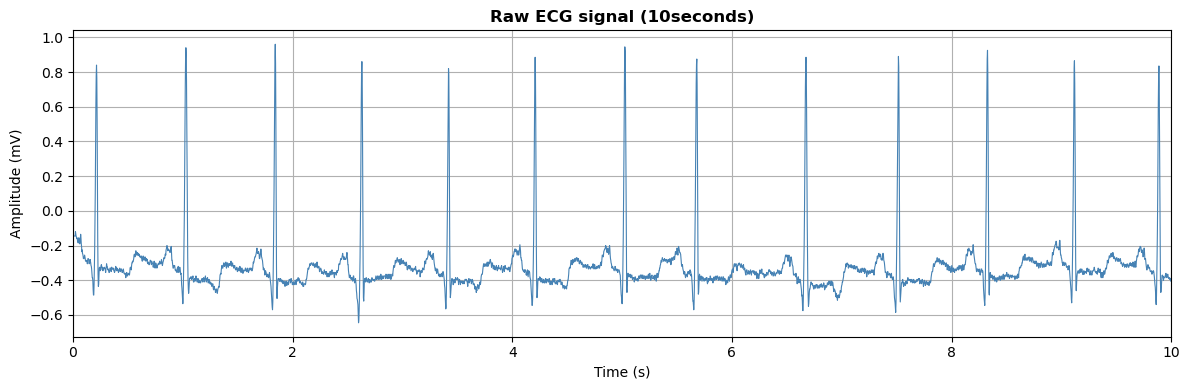

In [4]:
# Time axis
t=np.arange(len(ecg_signal))/fs

plt.figure(figsize=(12,4))
plt.plot(t,ecg_signal,color='steelblue',linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Raw ECG signal (10seconds)",weight ='bold')
plt.xlim([0,10])
plt.grid(True)
plt.tight_layout()
plt.savefig('output images/raw_ecg.png', dpi=150)
plt.show()

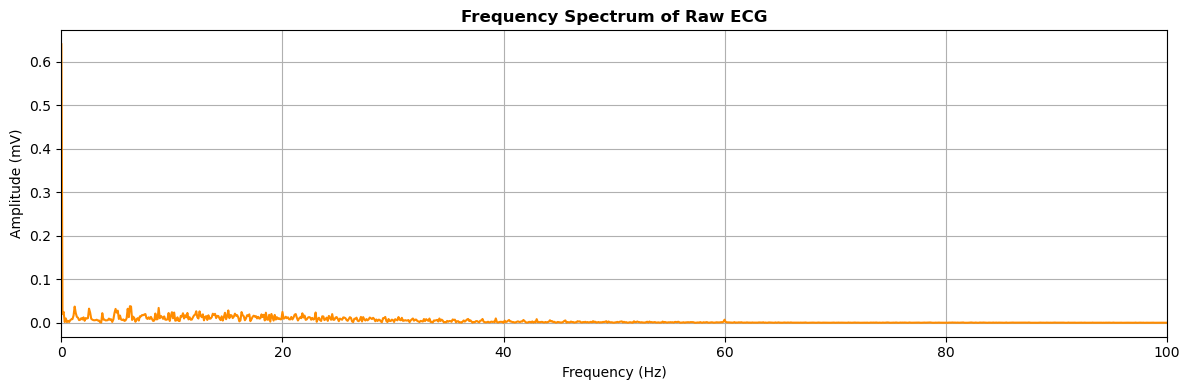

In [5]:
# FFT of Raw signal
n=len(ecg_signal)
fft_values=np.fft.rfft(ecg_signal)
fft_mag=2*np.abs(fft_values)/n
freq=np.fft.rfftfreq(n,1/fs)

plt.figure(figsize=(12,4))
plt.plot(freq,fft_mag,color='darkorange')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (mV)")
plt.title('Frequency Spectrum of Raw ECG',weight='bold')
plt.grid(True)
plt.xlim([0,100])
plt.tight_layout()
plt.savefig('output images/raw_ecg_spectrum.png', dpi=150)
plt.show()


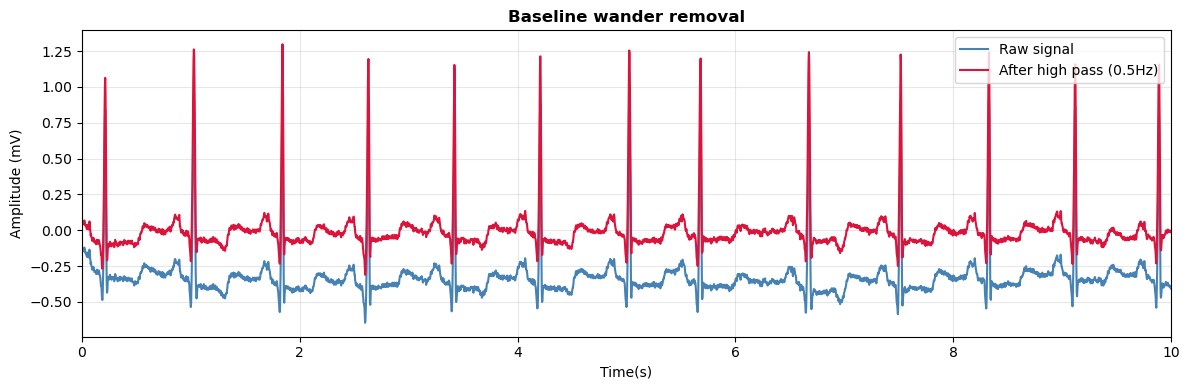

In [6]:
def high_pass(signal,cutoff,fs,order=4):
    nyq=fs/2
    normal_cutoff=cutoff/nyq
    b,a=butter(order,normal_cutoff,btype='high')
    return filtfilt(b,a,signal)

# Remove baseline wander — cut everything below 0.5 Hz
ecg_hp=high_pass(ecg_signal,cutoff=0.5,fs=fs)

# Plot original vs filtered
t=np.arange(len(ecg_signal))/fs

plt.figure(figsize=(12,4))
plt.plot(t,ecg_signal,label='Raw signal',color='steelblue')
plt.plot(t,ecg_hp,color='crimson',label='After high pass (0.5Hz)')
plt.xlabel("Time(s)")
plt.ylabel("Amplitude (mV)")
plt.title("Baseline wander removal",weight='bold')
plt.xlim([0,10])
plt.grid(True,alpha =0.3)
plt.legend()
plt.tight_layout()
plt.savefig('output images/ecg_highpass.png', dpi=150)
plt.show()

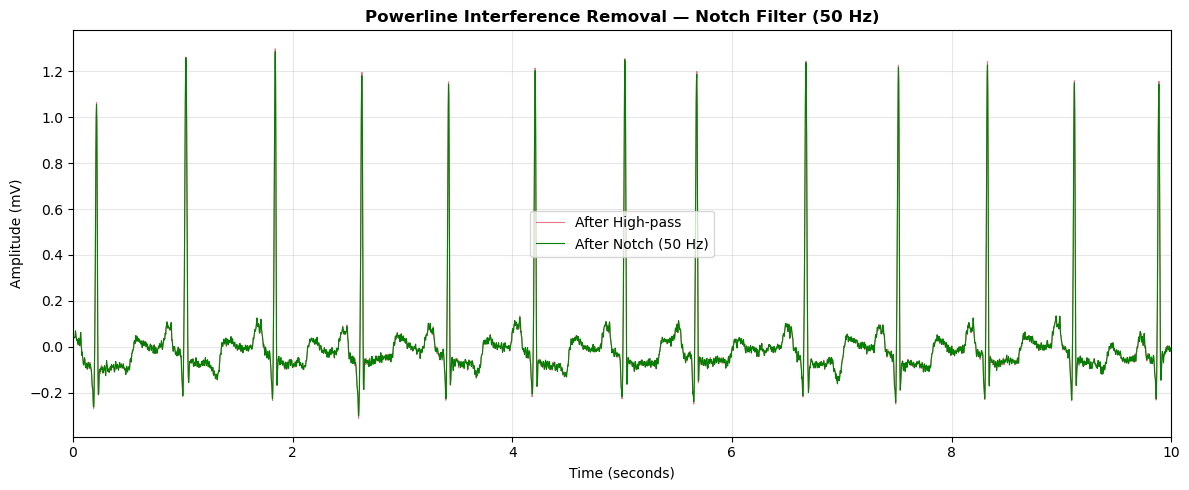

In [7]:
def notch_filter(signal,notch_freq,fs,quality_factor=30):
    b,a=iirnotch(notch_freq,quality_factor,fs)
    return filtfilt(b,a,signal)

# Apply notch at 50 Hz after high-pass
ecg_notch = notch_filter(ecg_hp,notch_freq=50,fs=fs)

plt.figure(figsize=(12, 5))
plt.plot(t, ecg_hp, label='After High-pass', color='crimson', alpha=0.6, linewidth=0.8)
plt.plot(t, ecg_notch, label='After Notch (50 Hz)', color='green', linewidth=0.8)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.title('Powerline Interference Removal — Notch Filter (50 Hz)',weight='bold')
plt.legend()
plt.xlim([0, 10])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output images/ecg_notch.png', dpi=150)
plt.show()

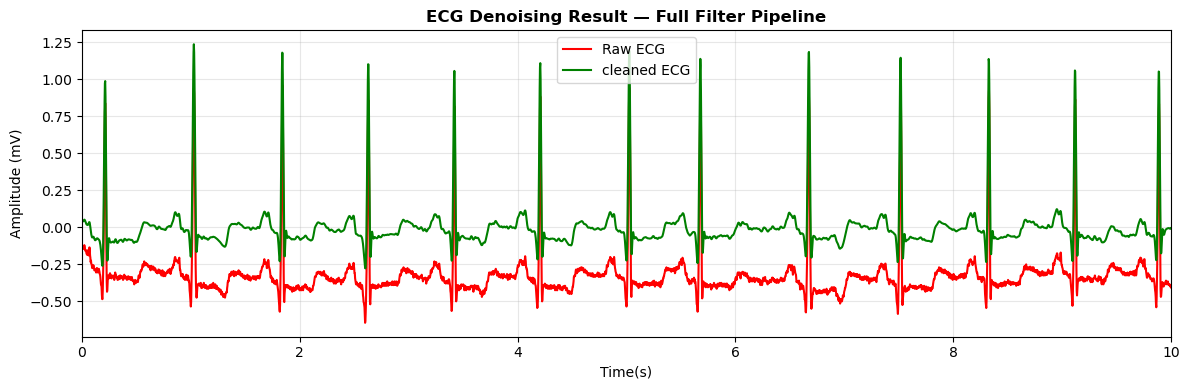

In [8]:
def low_pass(signal,cutoff,fs,order=4):
    nyq=fs/2
    normal_cutoff = cutoff/nyq
    b,a=butter(order,normal_cutoff,btype='low')
    return filtfilt(b,a,signal)

# Remove muscle artifact — cut everything above 40 Hz
ecg_clean=low_pass(ecg_notch,cutoff=40,fs=fs)

# Final comparison — raw vs fully cleaned
plt.figure(figsize=(12,4))
plt.plot(t,ecg_signal,color='red',label="Raw ECG")
plt.plot(t,ecg_clean,color="green",label='cleaned ECG')
plt.grid(True,alpha=0.3)
plt.legend()
plt.xlabel('Time(s)')
plt.ylabel("Amplitude (mV)")
plt.xlim([0,10])
plt.title('ECG Denoising Result — Full Filter Pipeline',weight='bold')
plt.tight_layout()
plt.savefig('output images/ecg_fully_cleaned.png', dpi=150)
plt.show()

In [9]:
def compute_snr(original,noise):
    signal_power =np.mean(original**2)
    noise_power=np.mean(noise**2)
    return 10*np.log10(signal_power/noise_power)

def compute_nrmse(refrence,estimated):
    rmse=np.sqrt(np.mean((refrence-estimated)**2))
    return rmse/(refrence.max()-refrence.min())

# Use ecg_clean as our reference (ground truth)
# Add synthetic noise to simulate a noisy recording
np.random.seed(42)
noise_level=0.1

# Three synthetic noise components
baseline=0.1*np.sin(2*np.pi*0.3*t)      # baseline wander
powerline=0.05*np.sin(2*np.pi*50*t)     # 50 Hz powerline
muscle=noise_level*np.random.rand(len(ecg_clean))   # muscle artifact

ecg_noisy=ecg_clean+baseline+powerline+muscle

# Apply full pipeline to the noisy signal
ecg_hp2=high_pass(ecg_noisy,cutoff=0.5,fs=fs)
ecg_notch2=notch_filter(ecg_hp2,notch_freq=50,fs=fs)
ecg_denoised =low_pass(ecg_notch2,cutoff=40,fs=fs)

# Compute metrics
snr_before=compute_snr(ecg_clean,ecg_noisy-ecg_clean)
snr_after =compute_snr(ecg_clean,ecg_denoised-ecg_clean)
snr_improvement=snr_after-snr_before

nrmse_before = compute_nrmse(ecg_clean, ecg_noisy)
nrmse_after = compute_nrmse(ecg_clean,ecg_denoised)
nrmse_reduction=((nrmse_before-nrmse_after)/nrmse_before)*100

print(f"SNR before filtering : {snr_before:.2f} dB")
print(f"SNR after filtering  : {snr_after:.2f} dB")
print(f"SNR improvement      : {snr_improvement:.2f} dB")
print(f"NRMSE before         : {nrmse_before:.4f}")
print(f"NRMSE after          : {nrmse_after:.4f}")




SNR before filtering : 4.55 dB
SNR after filtering  : 20.11 dB
SNR improvement      : 15.56 dB
NRMSE before         : 0.0646
NRMSE after          : 0.0108


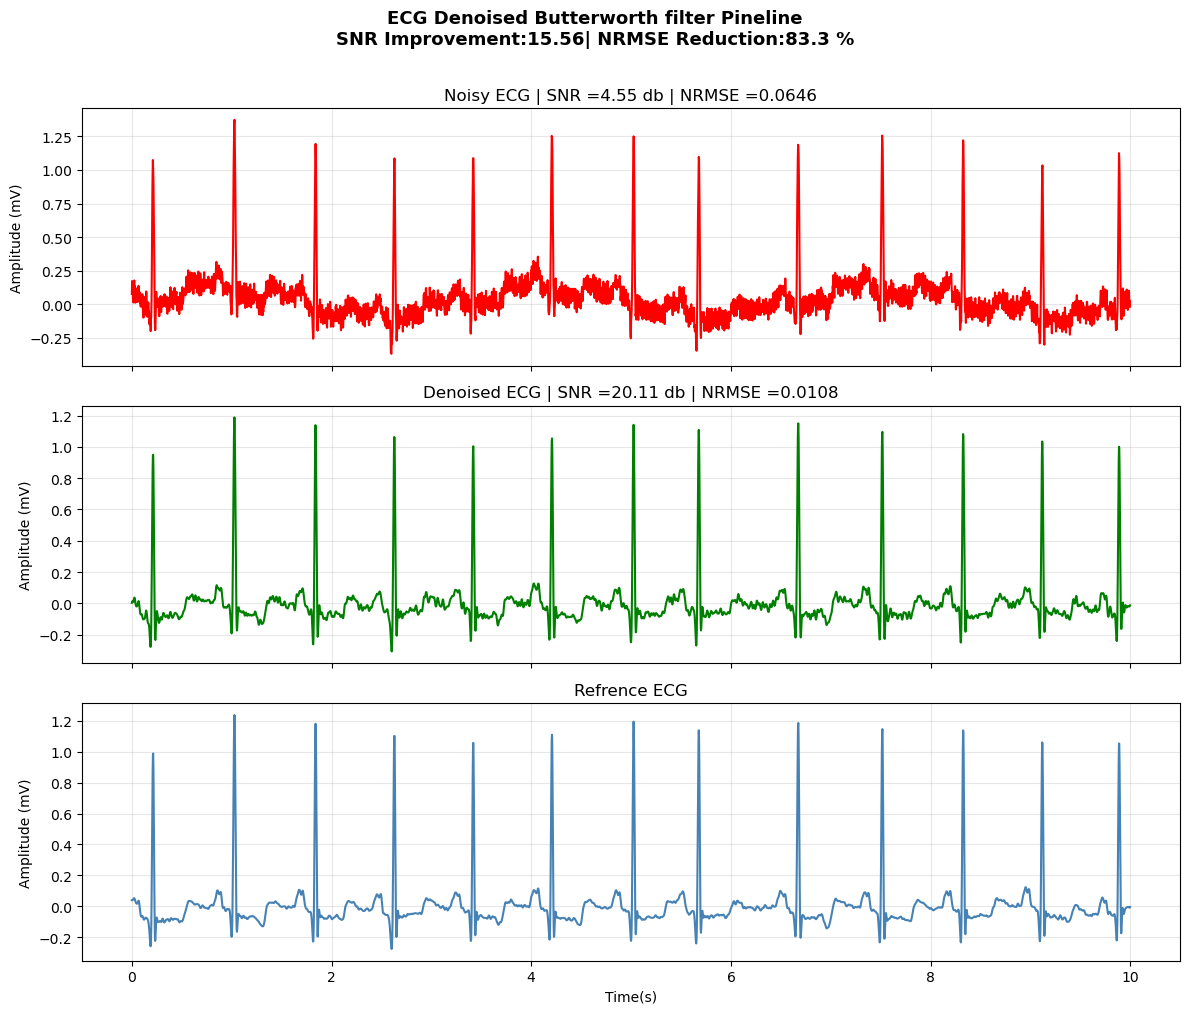

In [10]:
fig ,axes= plt.subplots(3,1,figsize=(12,10),sharex=True)

axes[0].plot(t,ecg_noisy,color='red')
axes[0].set_ylabel("Amplitude (mV)")
axes[0].set_title(f"Noisy ECG | SNR ={snr_before:0.2f} db | NRMSE ={nrmse_before :0.4f}")
axes[0].grid(True,alpha=0.3)

axes[1].plot(t,ecg_denoised,color='green')
axes[1].set_ylabel("Amplitude (mV)")
axes[1].set_title(f"Denoised ECG | SNR ={snr_after:0.2f} db | NRMSE ={nrmse_after :0.4f}")
axes[1].grid(True,alpha=0.3)

axes[2].plot(t,ecg_clean,color='steelblue')
axes[2].set_ylabel("Amplitude (mV)")
axes[2].set_title(f"Refrence ECG")
axes[2].set_xlabel("Time(s)")
axes[2].grid(True,alpha=0.3)

plt.suptitle(f"ECG Denoised Butterworth filter Pineline\nSNR Improvement:{snr_improvement:.2f}| NRMSE Reduction:{nrmse_reduction:0.1f} %",weight='bold',fontsize=13,y=1.01)
plt.tight_layout()
plt.savefig('output images/ecg_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:


def fir_bandpass(signal,lowcut,highcut,fs,numtaps=101):
    nyq=fs/2
    taps=firwin(numtaps,[lowcut/nyq,highcut/nyq],pass_zero=False,window='hamming')
    return filtfilt(taps,1.0,signal),taps,numtaps

ecg_fir,fir_taps,fir_taps01=fir_bandpass(ecg_noisy,lowcut=0.5,highcut=40,fs=fs,numtaps=101)

snr_fir   = compute_snr(ecg_clean, ecg_fir - ecg_clean)
nrmse_fir = compute_nrmse(ecg_clean, ecg_fir)

print(f"FIR SNR after filtering  : {snr_fir:.2f} dB")
print(f"FIR NRMSE after          : {nrmse_fir:.4f}")
print()
print(f"Butterworth SNR          : {snr_after:.2f} dB")
print(f"Butterworth NRMSE        : {nrmse_after:.4f}")

FIR SNR after filtering  : 7.95 dB
FIR NRMSE after          : 0.0437

Butterworth SNR          : 20.11 dB
Butterworth NRMSE        : 0.0108


In [12]:
# ── FIR Kaiser Bandpass Filter ──────────────────────────────────────────
# Design justification:
#   ripple_db = 60  → IEEE biomedical standard (1/1000th noise reduction)
#   width     = 1.5 → 873 taps computed by Kaiser formula, fits within
#                     3600 sample signal (max allowed: 1200 taps)
#                     Tradeoff: slightly wider transition band at 0.5Hz
#                     boundary — acceptable since baseline wander sits
#                     below 0.3Hz, leaving sufficient separation from ECG
# ──────────────────────────────────────────────────────────────────────

def fir_bandpass_kaiser(signal,lowcut,highcut,fs,ripple_db=60,width=1.5):
    nyq=fs/2
    
    # Kaiser formula: compute minimum taps and window shape (beta)
    numtaps,beta = kaiserord(ripple_db,width/nyq)
    if numtaps % 2==0:
        numtaps+=1         # FIR linear phase requires odd tap count
    
    if len(signal)<3*numtaps:
        print(f"Signal too short: {len(signal)} sample < 3 * {numtaps} taps")
        return None,numtaps
    
    print(f"kaiser formula -> {numtaps} taps | beta = {beta:.3f}")
    print(f"Filter memory -> {numtaps/fs :.3f} seconds")
    print(f"Signal length -> {len(signal)/fs:.1f} seconds")
    
    # Design FIR bandpass using Kaiser window
    taps=firwin(numtaps,[lowcut/nyq,highcut/nyq],
                pass_zero=False,window=("kaiser",beta))
    return filtfilt(taps,1.0,signal),numtaps

# ── Apply Filter ─────────────────────────────────────────────────────────
ecg_fir_kaiser ,n_taps=fir_bandpass_kaiser(ecg_noisy,
                                           lowcut=0.5,      # ECG lower bound - preserve P-wave content
                                           highcut=40,      # ECG upper bound - remove muscle artifact
                                           fs=fs,
                                           ripple_db=60,    # IEEE biomedical standard
                                           width=1.5       # taps should be within limits
                                           )

# ── Metrics ───────────────────────────────────────────────────────────────
snr_fir_kaiser = compute_snr(ecg_clean,ecg_fir_kaiser-ecg_clean)
nrmse_fir_kaiser = compute_nrmse(ecg_clean,ecg_fir_kaiser)

# ── Results Table ─────────────────────────────────────────────────────────
print(f"\nResults — Three Filter Comparison")
print(f"{'='*58}")
print(f"{'Filter':<25} {'SNR (dB)':>10} {'NRMSE':>10} {'Taps':>8}")
print(f"{'-'*58}")
print(f"{'FIR Kaiser':<25} {snr_fir_kaiser:>10.2f} "
      f"{nrmse_fir_kaiser:>10.4f} {n_taps:>8}")
print(f"{'FIR Hamming':<25} {snr_fir:>10.2f} "
      f"{nrmse_fir:>10.4f} {fir_taps01:>8}")
print(f"{'Butterworth IIR':<25} {snr_after:>10.2f} "
      f"{nrmse_after:>10.4f} {'8':>12}")
print(f"{'='*58}")



kaiser formula -> 873 taps | beta = 5.653
Filter memory -> 2.425 seconds
Signal length -> 10.0 seconds

Results — Three Filter Comparison
Filter                      SNR (dB)      NRMSE     Taps
----------------------------------------------------------
FIR Kaiser                     19.35     0.0118      873
FIR Hamming                     7.95     0.0437      101
Butterworth IIR                20.11     0.0108            8


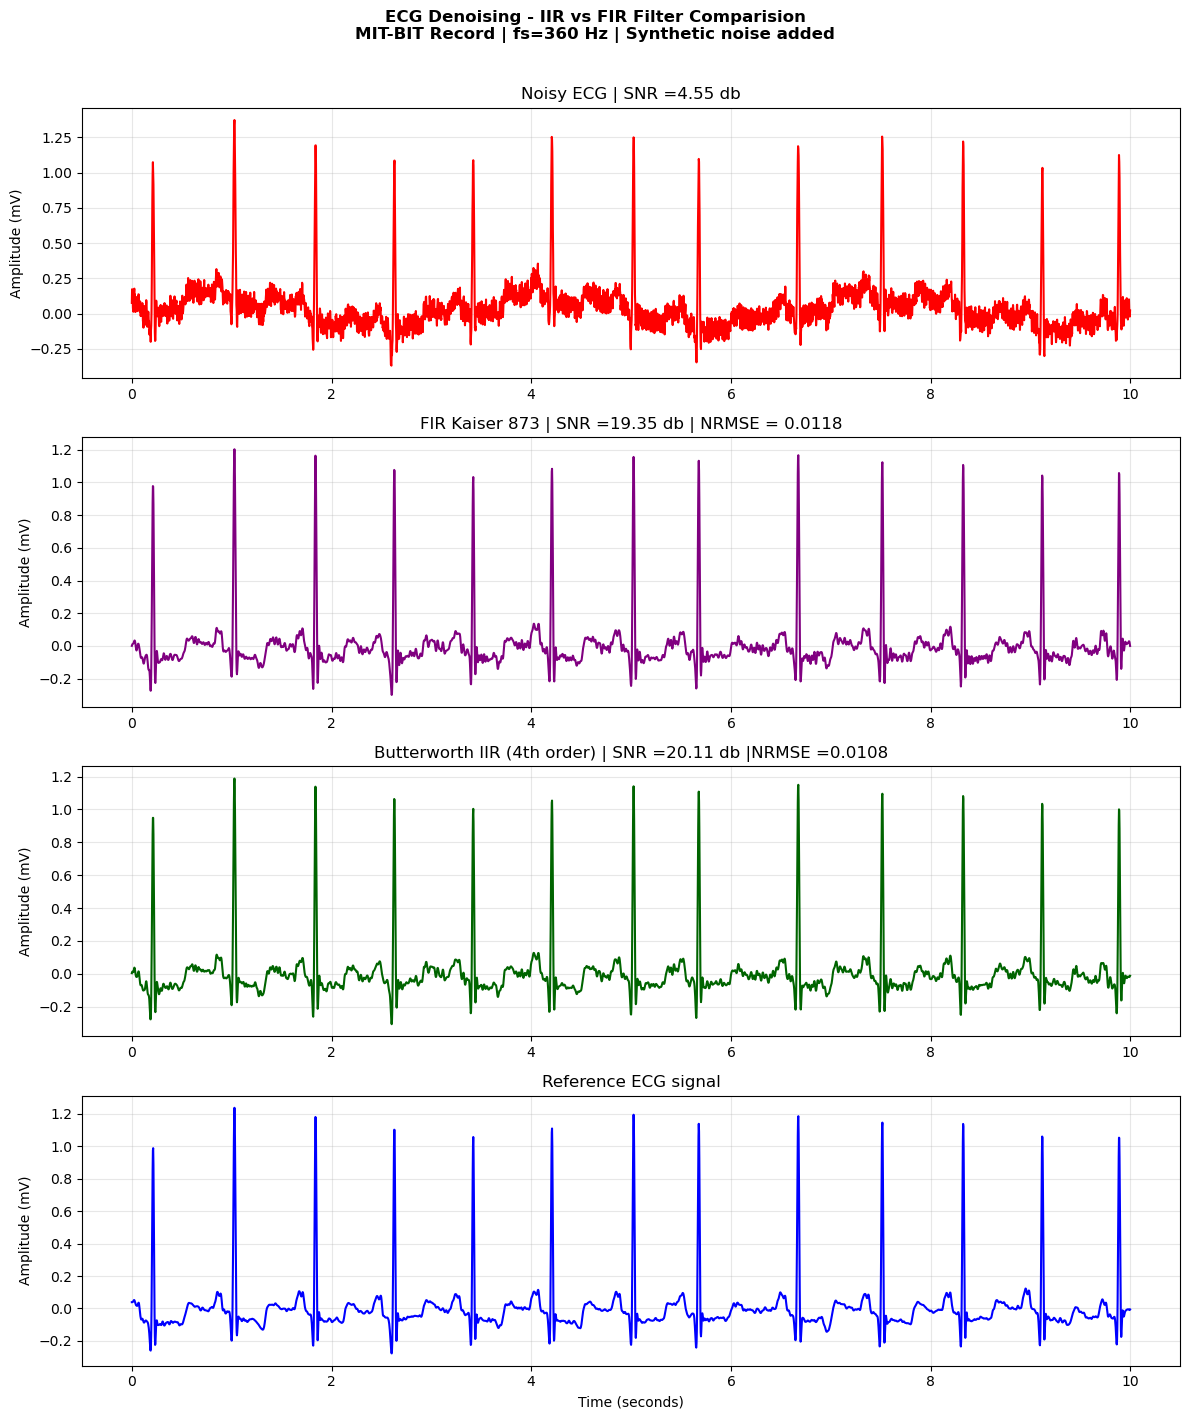

In [13]:
fix,axes=plt.subplots(4,1,figsize=(12,14))

signals=[
    (ecg_noisy,'red',f"Noisy ECG | SNR ={snr_before:.2f} db"),
    (ecg_fir_kaiser,'purple',f"FIR Kaiser {n_taps} | SNR ={snr_fir_kaiser :.2f} db | NRMSE = {nrmse_fir_kaiser:.4f}"),
    (ecg_denoised,"darkgreen",f"Butterworth IIR (4th order) | SNR ={snr_after:.2f} db |NRMSE ={nrmse_after:.4f}"),
    (ecg_clean,"blue",f"Reference ECG signal")
]

for ax,(sig,color,title) in zip(axes,signals):
    ax.plot(t,sig,color=color)
    ax.set_title(title)
    ax.set_ylabel("Amplitude (mV)")
    ax.grid(True,alpha=0.3)
    
axes[-1].set_xlabel("Time (seconds)")
plt.suptitle(
    "ECG Denoising - IIR vs FIR Filter Comparision\n"
    "MIT-BIT Record | fs=360 Hz | Synthetic noise added",
    fontsize=12,weight='bold',y=1.01
)
plt.tight_layout()
plt.savefig('output images/ecg_iir_vs_fir_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()

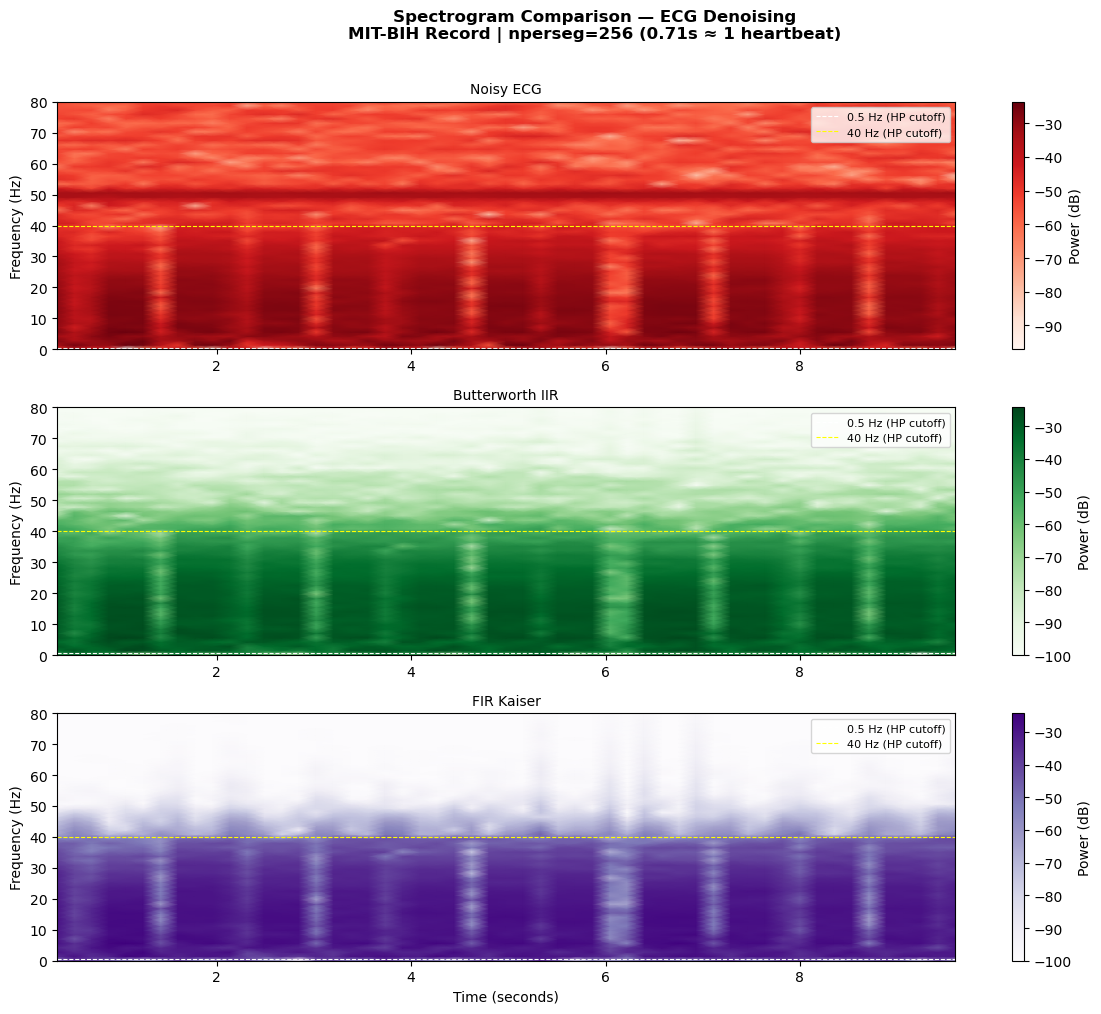

In [14]:

# ── Spectrogram parameters ───────────────────────────────────────────────
# nperseg = 256 samples = 0.71 seconds ≈ one heartbeat cycle
#A window of 256 samples at 360 Hz = 0.71 seconds is ideal.
# Chosen to balance time and frequency resolution (uncertainty principle)
# noverlap = 75% of nperseg → smooth time transitions
# ─────────────────────────────────────────────────────────────────────────
nperseg=256
noverlap=int(nperseg*0.75)     

# Compute spectrograms
f_noisy ,t_noisy ,Sxx_noisy = spectrogram(ecg_noisy,fs=fs,nperseg=nperseg,noverlap=noverlap)
f_butter,t_butter,Sxx_butter= spectrogram(ecg_denoised,fs=fs,nperseg=nperseg,noverlap=noverlap)
f_kaiser,t_kaiser,Sxx_kaiser = spectrogram(ecg_fir_kaiser,fs=fs,nperseg=nperseg,noverlap=noverlap)

# ── Plot ─────────────────────────────────────────────────────────────────
fig,axes=plt.subplots(3,1,figsize=(12,10))

dataset= [
    (t_noisy,  f_noisy,  Sxx_noisy,  'Noisy ECG','Reds'),
    (t_butter, f_butter, Sxx_butter, 'Butterworth IIR','Greens'),
    (t_kaiser, f_kaiser, Sxx_kaiser, 'FIR Kaiser','Purples'),
]

for ax,(t_s,f_s,Sxx,title,cmap) in zip(axes,dataset):
    # Log scale for better visual contrast
    im = ax.pcolormesh(t_s,f_s,10*np.log10(Sxx+1e-10),shading='gouraud',cmap=cmap)
    ax.set_ylim([0,80])
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(title , fontsize=10)
    ax.axhline(y=0.5,color='white',linewidth= 0.8,linestyle='--',label='0.5 Hz (HP cutoff)')
    ax.axhline(y=40,color='yellow',linewidth= 0.8,linestyle='--',label='40 Hz (HP cutoff)')
    ax.legend(loc='upper right',fontsize=8)
    plt.colorbar(im,ax=ax,label='Power (dB)')

axes[-1].set_xlabel('Time (seconds)')
plt.suptitle(
    'Spectrogram Comparison — ECG Denoising\n'
    'MIT-BIH Record | nperseg=256 (0.71s ≈ 1 heartbeat)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('output images/spectrogram_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
    
    

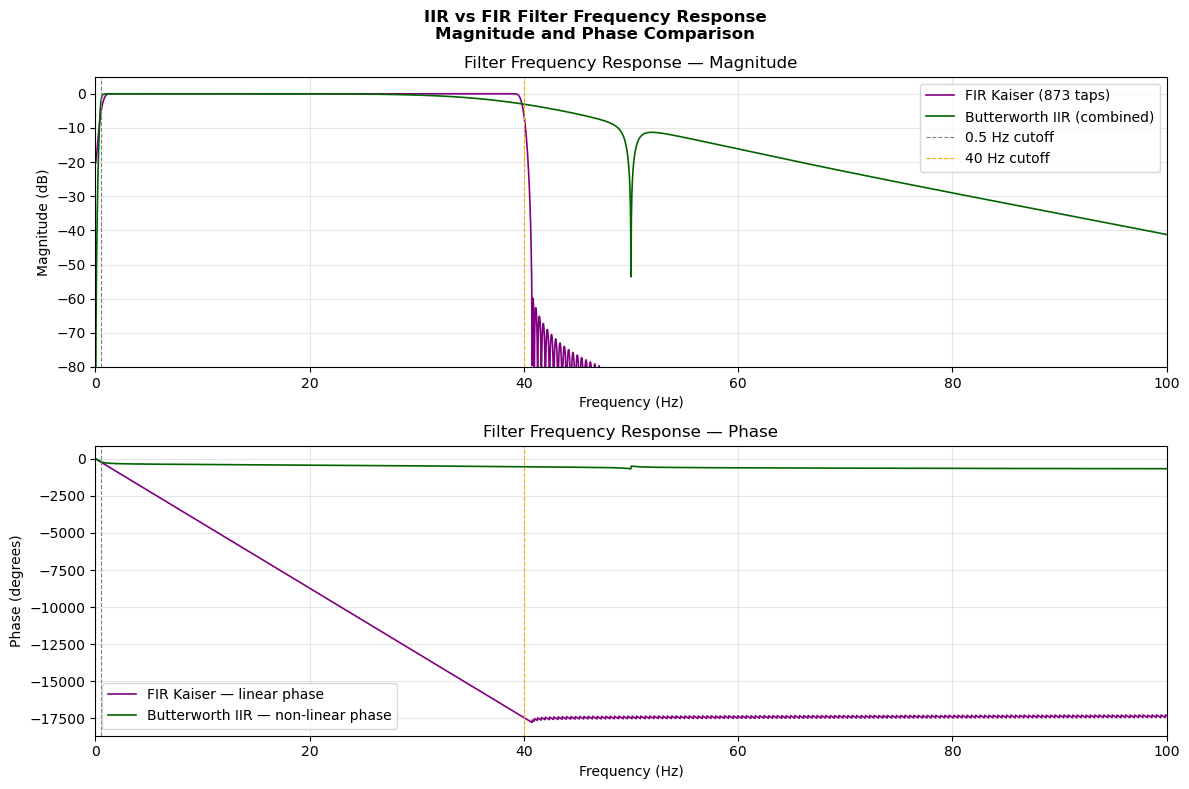

In [15]:
# ── Recompute filter coefficients for frequency response ─────────────────
# Butterworth pipeline: HP(0.5Hz) + Notch(50Hz) + LP(40Hz)
nyq = fs / 2

b_hp ,a_hp =butter(4,0.5/nyq,btype='high')
b_notch,a_notch=iirnotch(50,30,fs)
b_lp,a_lp=butter(4,40/nyq,btype='low')

# FIR Kaiser coefficients
numtaps ,beta=kaiserord(60,1.5/nyq)
if numtaps%2==0:
    numtaps+=1
fir_coeffs=firwin(numtaps,[0.5/nyq,40/nyq],pass_zero=False,window=('kaiser',beta))

# Frequency response
w_hp, h_hp = freqz(b_hp,a_hp,worN=8000,fs=fs)
w_notch,h_notch = freqz(b_notch,a_notch,worN=8000,fs=fs)
w_lp,    h_lp    = freqz(b_lp,    a_lp,    worN=8000, fs=fs)
w_fir,   h_fir   = freqz(fir_coeffs, 1.0,  worN=8000, fs=fs)

# Combined Butterworth response (multiply all three stages)
h_butter_combined=h_hp*h_notch*h_lp

# Plot
fig,axes=plt.subplots(2,1,figsize=(12,8))

# Magnitude response
axes[0].plot(w_fir,    20*np.log10(np.abs(h_fir) + 1e-10),
             color='purple',    linewidth=1.2, label='FIR Kaiser (873 taps)')
axes[0].plot(w_hp,     20*np.log10(np.abs(h_butter_combined) + 1e-10),
             color='darkgreen', linewidth=1.2, label='Butterworth IIR (combined)')
axes[0].axvline(x=0.5, color='gray',   linestyle='--',
                linewidth=0.8, label='0.5 Hz cutoff')
axes[0].axvline(x=40,  color='orange', linestyle='--',
                linewidth=0.8, label='40 Hz cutoff')
axes[0].set_xlim([0, 100])
axes[0].set_ylim([-80, 5])
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude (dB)')
axes[0].set_title('Filter Frequency Response — Magnitude')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Phase
axes[1].plot(w_fir,    np.unwrap(np.angle(h_fir)) * 180/np.pi,
             color='purple',    linewidth=1.2, label='FIR Kaiser — linear phase')
axes[1].plot(w_hp,     np.unwrap(np.angle(h_butter_combined)) * 180/np.pi,
             color='darkgreen', linewidth=1.2, label='Butterworth IIR — non-linear phase')
axes[1].axvline(x=0.5, color='gray',   linestyle='--', linewidth=0.8)
axes[1].axvline(x=40,  color='orange', linestyle='--', linewidth=0.8)
axes[1].set_xlim([0, 100])
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Phase (degrees)')
axes[1].set_title('Filter Frequency Response — Phase')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('IIR vs FIR Filter Frequency Response\n'
             'Magnitude and Phase Comparison',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('output images/filter_frequency_response.png',
            dpi=150, bbox_inches='tight')
plt.show()

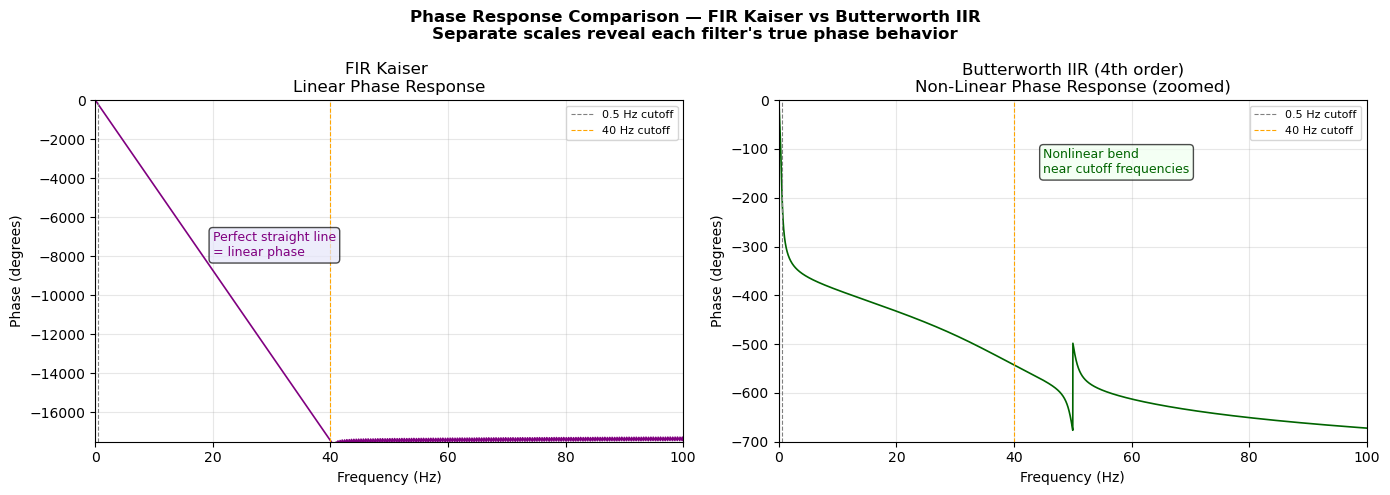

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: FIR Kaiser — full scale shows perfect linearity ────────────────
axes[0].plot(w_fir,
             np.unwrap(np.angle(h_fir)) * 180/np.pi,
             color='purple', linewidth=1.2)
axes[0].axvline(x=0.5, color='gray',   linestyle='--',
                linewidth=0.8, label='0.5 Hz cutoff')
axes[0].axvline(x=40,  color='orange', linestyle='--',
                linewidth=0.8, label='40 Hz cutoff')
axes[0].set_xlim([0, 100])
axes[0].set_ylim([-17500, 0])
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Phase (degrees)')
axes[0].set_title('FIR Kaiser \nLinear Phase Response')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Annotate linearity
axes[0].annotate('Perfect straight line\n= linear phase',
                 xy=(20, -8000),
                 fontsize=9, color='purple',
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='lavender', alpha=0.7))

# ── Right: Butterworth IIR — zoomed to show nonlinearity ─────────────────
axes[1].plot(w_hp,
             np.unwrap(np.angle(h_butter_combined)) * 180/np.pi,
             color='darkgreen', linewidth=1.2)
axes[1].axvline(x=0.5, color='gray',   linestyle='--',
                linewidth=0.8, label='0.5 Hz cutoff')
axes[1].axvline(x=40,  color='orange', linestyle='--',
                linewidth=0.8, label='40 Hz cutoff')
axes[1].set_xlim([0, 100])
axes[1].set_ylim([-700, 0])   # zoomed — reveals nonlinear curve
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Phase (degrees)')
axes[1].set_title('Butterworth IIR (4th order)\nNon-Linear Phase Response (zoomed)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Annotate nonlinearity
axes[1].annotate('Nonlinear bend\nnear cutoff frequencies',
                 xy=(45, -150),
                 fontsize=9, color='darkgreen',
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='honeydew', alpha=0.7))

plt.suptitle('Phase Response Comparison — FIR Kaiser vs Butterworth IIR\n'
             'Separate scales reveal each filter\'s true phase behavior',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('output images/phase_response_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [17]:


records     = ['100', '101', '103', '105']
results     = {}
conditions  = {
    '100': 'Normal sinus rhythm',
    '101': 'Mild arrhythmia',
    '103': 'Frequent ectopic beats',
    '105': 'Bundle branch block'
}

for rec_id in records:
    record = wfdb.rdrecord(rec_id,
                           sampfrom=0,
                           sampto=3600,
                           pn_dir='mitdb')
    sig    = record.p_signal[:, 0]
    fs_rec = record.fs
    t_rec  = np.arange(len(sig)) / fs_rec

    # ── Clean reference (preprocessed — not absolute ground truth) ────────
    # Note: MIT-BIH records are real patient recordings with no perfect
    # ground truth. This preprocessed reference is our best approximation.
    sig_hp_ref    = high_pass(sig,       cutoff=0.5,    fs=fs_rec)
    sig_notch_ref = notch_filter(sig_hp_ref,   notch_freq=50, fs=fs_rec)
    sig_clean     = low_pass(sig_notch_ref, cutoff=40,  fs=fs_rec)

    # ── Add synthetic noise ───────────────────────────────────────────────
    np.random.seed(42)
    noise = (0.1  * np.sin(2 * np.pi * 0.3 * t_rec) +
             0.05 * np.sin(2 * np.pi * 50  * t_rec) +
             0.1  * np.random.randn(len(sig)))
    sig_noisy = sig_clean + noise

    # ── Apply Butterworth pipeline + measure execution time ───────────────
    t_start    = time.perf_counter()
    sig_hp     = high_pass(sig_noisy, cutoff=0.5,    fs=fs_rec)
    sig_notch  = notch_filter(sig_hp,       notch_freq=50, fs=fs_rec)
    sig_butter = low_pass(sig_notch,  cutoff=40,     fs=fs_rec)
    time_butter = (time.perf_counter() - t_start) * 1000  # ms

    # ── Apply FIR Kaiser pipeline + measure execution time ────────────────
    t_start    = time.perf_counter()
    sig_kaiser, n_taps = fir_bandpass_kaiser(sig_noisy,
                                              lowcut=0.5,
                                              highcut=40,
                                              fs=fs_rec,
                                              ripple_db=60,
                                              width=1.5)
    time_kaiser = (time.perf_counter() - t_start) * 1000  # ms

    # ── Metrics ───────────────────────────────────────────────────────────
    snr_before   = compute_snr(sig_clean, sig_noisy  - sig_clean)
    snr_butter   = compute_snr(sig_clean, sig_butter - sig_clean)
    snr_kaiser   = compute_snr(sig_clean, sig_kaiser - sig_clean)
    delta_butter = snr_butter - snr_before   # ΔSNR
    delta_kaiser = snr_kaiser - snr_before   # ΔSNR
    nrmse_butter = compute_nrmse(sig_clean,  sig_butter)
    nrmse_kaiser = compute_nrmse(sig_clean,  sig_kaiser)

    results[rec_id] = {
        'condition'   : conditions[rec_id],
        'snr_before'  : snr_before,
        'snr_butter'  : snr_butter,
        'snr_kaiser'  : snr_kaiser,
        'delta_butter': delta_butter,
        'delta_kaiser': delta_kaiser,
        'nrmse_butter': nrmse_butter,
        'nrmse_kaiser': nrmse_kaiser,
        'time_butter' : time_butter,
        'time_kaiser' : time_kaiser,
    }

# ── Compute mean ± std ────────────────────────────────────────────────────
delta_butter_vals = [r['delta_butter'] for r in results.values()]
delta_kaiser_vals = [r['delta_kaiser'] for r in results.values()]
nrmse_butter_vals = [r['nrmse_butter'] for r in results.values()]
nrmse_kaiser_vals = [r['nrmse_kaiser'] for r in results.values()]
time_butter_vals  = [r['time_butter']  for r in results.values()]
time_kaiser_vals  = [r['time_kaiser']  for r in results.values()]

# ── Print enhanced results table ──────────────────────────────────────────
print(f"\n{'='*90}")
print(f"{'Multi-Record Validation — ECG Denoising Pipeline':^90}")
print(f"{'Note: Clean reference = preprocessed signal, not absolute ground truth':^90}")
print(f"{'='*90}")
print(f"{'Record':<8} {'Condition':<26} {'SNR₀':>6} "
      f"{'IIR SNR':>8} {'ΔSNR IIR':>9} "
      f"{'FIR SNR':>8} {'ΔSNR FIR':>9} "
      f"{'NRMSE IIR':>10} {'NRMSE FIR':>10}")
print(f"{'-'*90}")

for rec_id, r in results.items():
    print(f"{rec_id:<8} "
          f"{r['condition']:<26} "
          f"{r['snr_before']:>6.2f} "
          f"{r['snr_butter']:>8.2f} "
          f"{r['delta_butter']:>+9.2f} "
          f"{r['snr_kaiser']:>8.2f} "
          f"{r['delta_kaiser']:>+9.2f} "
          f"{r['nrmse_butter']:>10.4f} "
          f"{r['nrmse_kaiser']:>10.4f}")

print(f"{'-'*90}")
print(f"{'Mean':<34} "
      f"{'':>6} "
      f"{'':>8} "
      f"{np.mean(delta_butter_vals):>+9.2f} "
      f"{'':>8} "
      f"{np.mean(delta_kaiser_vals):>+9.2f} "
      f"{np.mean(nrmse_butter_vals):>10.4f} "
      f"{np.mean(nrmse_kaiser_vals):>10.4f}")
print(f"{'Std Dev':<34} "
      f"{'':>6} "
      f"{'':>8} "
      f"{np.std(delta_butter_vals):>9.2f} "
      f"{'':>8} "
      f"{np.std(delta_kaiser_vals):>9.2f} "
      f"{np.std(nrmse_butter_vals):>10.4f} "
      f"{np.std(nrmse_kaiser_vals):>10.4f}")
print(f"{'='*90}")
print(f"\nExecution Time:")
print(f"  Butterworth IIR : {np.mean(time_butter_vals):.2f} ± "
      f"{np.std(time_butter_vals):.2f} ms")
print(f"  FIR Kaiser      : {np.mean(time_kaiser_vals):.2f} ± "
      f"{np.std(time_kaiser_vals):.2f} ms")

kaiser formula -> 873 taps | beta = 5.653
Filter memory -> 2.425 seconds
Signal length -> 10.0 seconds
kaiser formula -> 873 taps | beta = 5.653
Filter memory -> 2.425 seconds
Signal length -> 10.0 seconds
kaiser formula -> 873 taps | beta = 5.653
Filter memory -> 2.425 seconds
Signal length -> 10.0 seconds
kaiser formula -> 873 taps | beta = 5.653
Filter memory -> 2.425 seconds
Signal length -> 10.0 seconds

                     Multi-Record Validation — ECG Denoising Pipeline                     
          Note: Clean reference = preprocessed signal, not absolute ground truth          
Record   Condition                    SNR₀  IIR SNR  ΔSNR IIR  FIR SNR  ΔSNR FIR  NRMSE IIR  NRMSE FIR
------------------------------------------------------------------------------------------
100      Normal sinus rhythm          2.25    10.95     +8.70    10.64     +8.40     0.0309     0.0320
101      Mild arrhythmia              3.48    12.28     +8.80    12.04     +8.56     0.0268     0.0275
103  

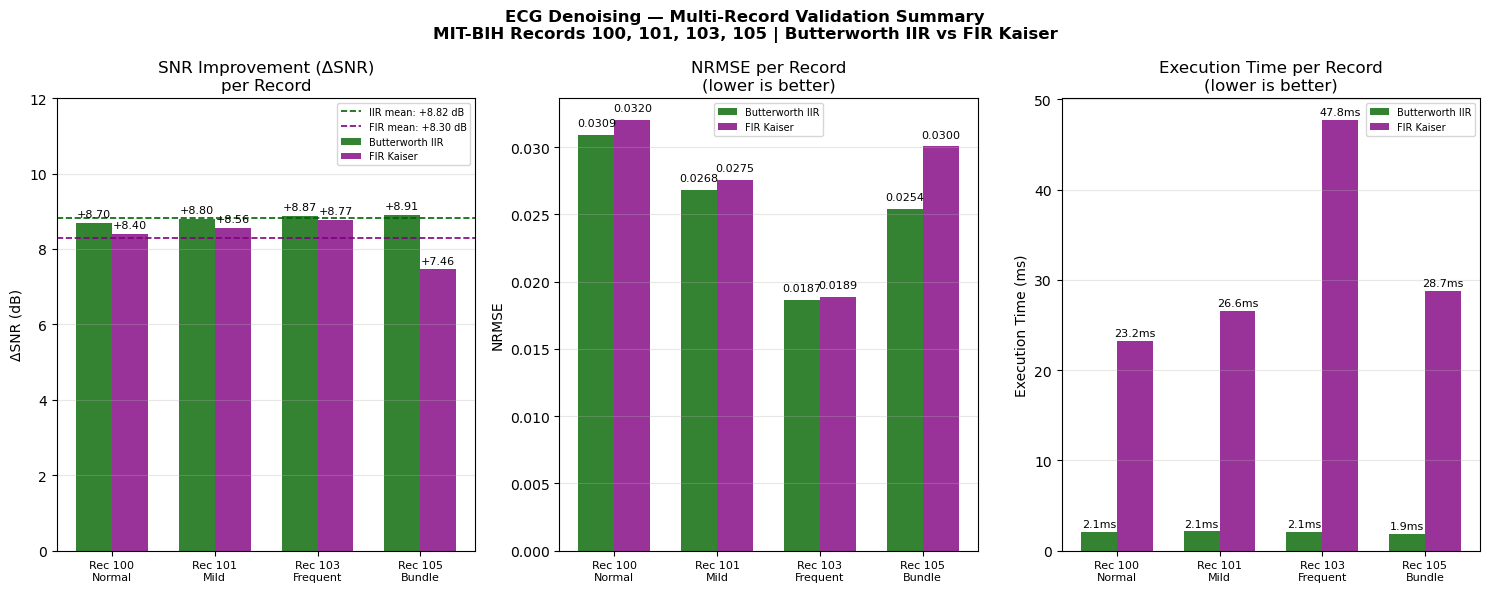

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

rec_labels = [f"Rec {r}\n{results[r]['condition'].split()[0]}"
              for r in records]
x          = np.arange(len(records))
width      = 0.35

# ── Plot 1: ΔSNR comparison ───────────────────────────────────────────────
delta_b = [results[r]['delta_butter'] for r in records]
delta_k = [results[r]['delta_kaiser'] for r in records]

bars1 = axes[0].bar(x - width/2, delta_b, width,
                     label='Butterworth IIR',
                     color='darkgreen', alpha=0.8)
bars2 = axes[0].bar(x + width/2, delta_k, width,
                     label='FIR Kaiser',
                     color='purple', alpha=0.8)

# Add mean lines
axes[0].axhline(y=np.mean(delta_b), color='darkgreen',
                linestyle='--', linewidth=1.2,
                label=f'IIR mean: +{np.mean(delta_b):.2f} dB')
axes[0].axhline(y=np.mean(delta_k), color='purple',
                linestyle='--', linewidth=1.2,
                label=f'FIR mean: +{np.mean(delta_k):.2f} dB')

# Value labels on bars
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'+{bar.get_height():.2f}',
                 ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'+{bar.get_height():.2f}',
                 ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(rec_labels, fontsize=8)
axes[0].set_ylabel('ΔSNR (dB)')
axes[0].set_title('SNR Improvement (ΔSNR)\nper Record')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 12])

# ── Plot 2: NRMSE comparison ──────────────────────────────────────────────
nrmse_b = [results[r]['nrmse_butter'] for r in records]
nrmse_k = [results[r]['nrmse_kaiser'] for r in records]

bars3 = axes[1].bar(x - width/2, nrmse_b, width,
                     label='Butterworth IIR',
                     color='darkgreen', alpha=0.8)
bars4 = axes[1].bar(x + width/2, nrmse_k, width,
                     label='FIR Kaiser',
                     color='purple', alpha=0.8)

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0005,
                 f'{bar.get_height():.4f}',
                 ha='center', va='bottom', fontsize=8)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0005,
                 f'{bar.get_height():.4f}',
                 ha='center', va='bottom', fontsize=8)

axes[1].set_xticks(x)
axes[1].set_xticklabels(rec_labels, fontsize=8)
axes[1].set_ylabel('NRMSE')
axes[1].set_title('NRMSE per Record\n(lower is better)')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3, axis='y')

# ── Plot 3: Execution time ────────────────────────────────────────────────
time_b = [results[r]['time_butter'] for r in records]
time_k = [results[r]['time_kaiser'] for r in records]

bars5 = axes[2].bar(x - width/2, time_b, width,
                     label='Butterworth IIR',
                     color='darkgreen', alpha=0.8)
bars6 = axes[2].bar(x + width/2, time_k, width,
                     label='FIR Kaiser',
                     color='purple', alpha=0.8)

for bar in bars5:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}ms',
                 ha='center', va='bottom', fontsize=8)
for bar in bars6:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}ms',
                 ha='center', va='bottom', fontsize=8)

axes[2].set_xticks(x)
axes[2].set_xticklabels(rec_labels, fontsize=8)
axes[2].set_ylabel('Execution Time (ms)')
axes[2].set_title('Execution Time per Record\n(lower is better)')
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle(
    'ECG Denoising — Multi-Record Validation Summary\n'
    'MIT-BIH Records 100, 101, 103, 105 | Butterworth IIR vs FIR Kaiser',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('output images/multi_record_bar_chart.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [19]:

# Load cardiologist annotations for Record 100
annotation = wfdb.rdann('100', extension='atr',
                        sampfrom=0, sampto=3600,
                        pn_dir='mitdb')

# annotation.sample contains the exact sample indices of each R-peak
r_peaks_true = annotation.sample

print(f"Number of annotated R-peaks: {len(r_peaks_true)}")
print(f"First 5 R-peak sample indices: {r_peaks_true[:5]}")
print(f"First 5 R-peak times (seconds): {r_peaks_true[:5]/fs}")

Number of annotated R-peaks: 14
First 5 R-peak sample indices: [ 18  77 370 662 946]
First 5 R-peak times (seconds): [0.05       0.21388889 1.02777778 1.83888889 2.62777778]


In [20]:
def pan_tompkins_detector(signal,fs):
    # Step 1: Bandpass filter 5-15 Hz — isolates QRS frequency range
    nyq =fs/2
    b,a =butter(2,[5/nyq,15/nyq],btype='band')
    filtered = filtfilt(b,a,signal)
    
    # Step 2: Differentiate — enhances steep R-peak slopes
    diff= np.diff(filtered)
    diff=np.append(diff,0)
    
    # Step 3: Square — amplifies large slopes, makes all positive
    squared = diff**2
    
    # Step 4: Moving window integration — smooths into detectable peaks
    window_size = int(0.15*fs)
    integrated = np.convolve(squared,np.ones(window_size)/window_size,mode='same')
    
    # Step 5: Adaptive threshold — detect peaks above noise floor
    threshold = 0.3 * np.max(integrated)     # 30% of peak — standard starting point
    
    peaks =[]
    min_distance = int(0.2 * fs)    # 200ms minimum between beats (300 bpm max)
    
    i=0
    while i< len(integrated):
        if integrated[i] > threshold :
            # Find local maximum in this region
            window_end=min(i+min_distance,len(integrated))
            local_max_idx=i+np.argmax(integrated[i:window_end])
            peaks.append(local_max_idx)
            i=local_max_idx+min_distance
        else:
            i+=1
    return np.array(peaks),integrated,threshold

# Apply to denoised signal
r_peaks_detected,integrated_signal,threshold = pan_tompkins_detector(ecg_denoised,fs)

print(f"Annotated R-peak : {len(r_peaks_true)}")
print(f"detected R-peak : {len(r_peaks_detected)}")   
print(f"Dectected indices : {r_peaks_detected}")

Annotated R-peak : 14
detected R-peak : 13
Dectected indices : [  77  370  662  946 1232 1516 1809 2045 2403 2706 2998 3282 3560]


In [21]:
def evaluate_detection(true_peaks, detected_peaks, fs, tolerance_ms=150):
    tolerance_samples = int(tolerance_ms / 1000 * fs)  # 150ms → 54 samples

    tp = 0  # true positive — correctly detected
    matched_true = set()

    for det in detected_peaks:
        # Check if any true peak falls within tolerance window
        distances = np.abs(true_peaks - det)
        min_idx = np.argmin(distances)
        if distances[min_idx] <= tolerance_samples and min_idx not in matched_true:
            tp += 1
            matched_true.add(min_idx)

    fn = len(true_peaks) - tp       # missed peaks
    fp = len(detected_peaks) - tp   # false detections

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_score    = (2 * sensitivity * precision / (sensitivity + precision)
                   if (sensitivity + precision) > 0 else 0)

    return {
        'TP': tp, 'FN': fn, 'FP': fp,
        'Sensitivity': sensitivity,
        'Precision': precision,
        'F1': f1_score
    }

metrics = evaluate_detection(r_peaks_true, r_peaks_detected, fs)

print(f"True Positives  : {metrics['TP']}")
print(f"False Negatives : {metrics['FN']}")
print(f"False Positives : {metrics['FP']}")
print(f"Sensitivity     : {metrics['Sensitivity']*100:.2f}%")
print(f"Precision       : {metrics['Precision']*100:.2f}%")
print(f"F1 Score        : {metrics['F1']*100:.2f}%")

True Positives  : 13
False Negatives : 1
False Positives : 0
Sensitivity     : 92.86%
Precision       : 100.00%
F1 Score        : 96.30%


In [22]:
# Run Pan-Tompkins on the NOISY signal (before filtering)
r_peaks_noisy, _, _ = pan_tompkins_detector(ecg_noisy, fs)

metrics_noisy = evaluate_detection(r_peaks_true, r_peaks_noisy, fs)

print("=" * 50)
print("R-Peak Detection — Noisy vs Denoised Signal")
print("=" * 50)
print(f"{'Metric':<15} {'Noisy':>12} {'Denoised':>12}")
print("-" * 50)
print(f"{'TP':<15} {metrics_noisy['TP']:>12} {metrics['TP']:>12}")
print(f"{'FN':<15} {metrics_noisy['FN']:>12} {metrics['FN']:>12}")
print(f"{'FP':<15} {metrics_noisy['FP']:>12} {metrics['FP']:>12}")
print(f"{'Sensitivity':<15} {metrics_noisy['Sensitivity']*100:>11.2f}% {metrics['Sensitivity']*100:>11.2f}%")
print(f"{'Precision':<15} {metrics_noisy['Precision']*100:>11.2f}% {metrics['Precision']*100:>11.2f}%")
print(f"{'F1 Score':<15} {metrics_noisy['F1']*100:>11.2f}% {metrics['F1']*100:>11.2f}%")
print("=" * 50)

R-Peak Detection — Noisy vs Denoised Signal
Metric                 Noisy     Denoised
--------------------------------------------------
TP                        13           13
FN                         1            1
FP                         0            0
Sensitivity           92.86%       92.86%
Precision            100.00%      100.00%
F1 Score              96.30%       96.30%


In [23]:
# ── Add harder noise: concentrated in Pan-Tompkins' own passband ─────────
# This tests whether our denoising pipeline provides real benefit
# even after Pan-Tompkins' internal 5-15Hz filter is applied
np.random.seed(42)

hard_noise = (0.1  * np.sin(2 * np.pi * 0.3 * t) +      # baseline wander
              0.05 * np.sin(2 * np.pi * 50  * t) +      # powerline
              0.1  * np.random.randn(len(ecg_clean)) +   # muscle artifact
              0.3  * np.sin(2 * np.pi * 10  * t))        # NEW: in-band noise

ecg_hard_noisy = ecg_clean + hard_noise

# Apply our full denoising pipeline to this harder noise
ecg_hp_hard     = high_pass(ecg_hard_noisy, cutoff=0.5,    fs=fs)
ecg_notch_hard  = notch_filter(ecg_hp_hard,       notch_freq=50, fs=fs)
ecg_denoised_hard = low_pass(ecg_notch_hard, cutoff=40,   fs=fs)

# Run Pan-Tompkins on both versions
r_peaks_hard_noisy,   _, _ = pan_tompkins_detector(ecg_hard_noisy, fs)
r_peaks_hard_denoised, _, _ = pan_tompkins_detector(ecg_denoised_hard, fs)

metrics_hard_noisy   = evaluate_detection(r_peaks_true, r_peaks_hard_noisy, fs)
metrics_hard_denoised = evaluate_detection(r_peaks_true, r_peaks_hard_denoised, fs)

print("=" * 55)
print("R-Peak Detection — Stress Test (10Hz in-band noise)")
print("=" * 55)
print(f"{'Metric':<15} {'Noisy':>15} {'Denoised':>15}")
print("-" * 55)
print(f"{'TP':<15} {metrics_hard_noisy['TP']:>15} {metrics_hard_denoised['TP']:>15}")
print(f"{'FN':<15} {metrics_hard_noisy['FN']:>15} {metrics_hard_denoised['FN']:>15}")
print(f"{'FP':<15} {metrics_hard_noisy['FP']:>15} {metrics_hard_denoised['FP']:>15}")
print(f"{'Sensitivity':<15} {metrics_hard_noisy['Sensitivity']*100:>14.2f}% {metrics_hard_denoised['Sensitivity']*100:>14.2f}%")
print(f"{'Precision':<15} {metrics_hard_noisy['Precision']*100:>14.2f}% {metrics_hard_denoised['Precision']*100:>14.2f}%")
print(f"{'F1 Score':<15} {metrics_hard_noisy['F1']*100:>14.2f}% {metrics_hard_denoised['F1']*100:>14.2f}%")
print("=" * 55)

R-Peak Detection — Stress Test (10Hz in-band noise)
Metric                    Noisy        Denoised
-------------------------------------------------------
TP                           10              10
FN                            4               4
FP                            0               0
Sensitivity              71.43%          71.43%
Precision               100.00%         100.00%
F1 Score                 83.33%          83.33%


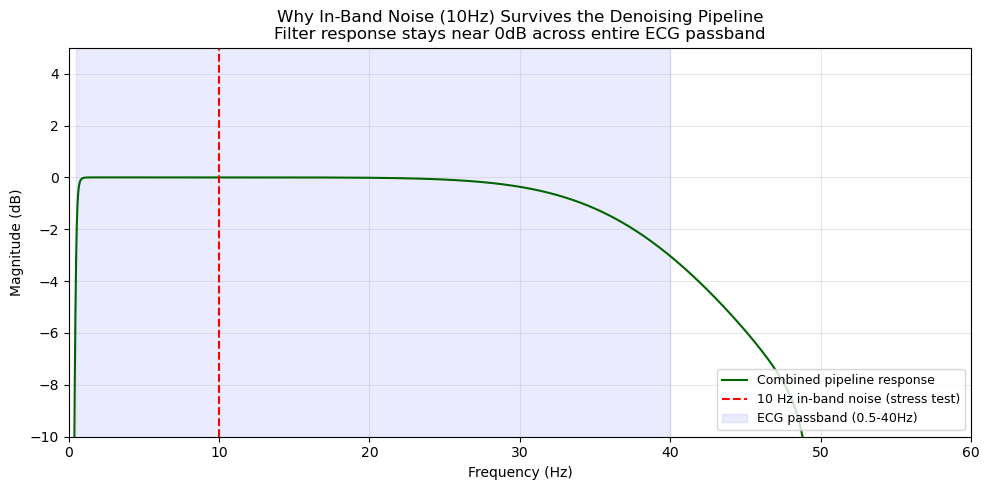

In [24]:
# ── Magnitude response showing why 10Hz noise survives all filters ─────────
from scipy.signal import freqz

nyq = fs / 2
b_hp, a_hp = butter(4, 0.5/nyq, btype='high')
b_notch, a_notch = iirnotch(50, 30, fs)
b_lp, a_lp = butter(4, 40/nyq, btype='low')

w, h_hp = freqz(b_hp, a_hp, worN=8000, fs=fs)
_, h_notch = freqz(b_notch, a_notch, worN=8000, fs=fs)
_, h_lp = freqz(b_lp, a_lp, worN=8000, fs=fs)
h_combined = h_hp * h_notch * h_lp

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(w, 20*np.log10(np.abs(h_combined) + 1e-10),
        color='darkgreen', linewidth=1.5, label='Combined pipeline response')
ax.axvline(x=10, color='red', linestyle='--', linewidth=1.5,
           label='10 Hz in-band noise (stress test)')
ax.axvspan(0.5, 40, alpha=0.08, color='blue', label='ECG passband (0.5-40Hz)')
ax.set_xlim([0, 60])
ax.set_ylim([-10, 5])
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (dB)')
ax.set_title('Why In-Band Noise (10Hz) Survives the Denoising Pipeline\n'
             'Filter response stays near 0dB across entire ECG passband')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output images/inband_noise_limitation.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ── R-peak amplitude preservation ─────────────────────────────────────────
# Compare amplitude at true annotated R-peak locations
amp_clean   = ecg_clean[r_peaks_true]
amp_noisy   = ecg_noisy[r_peaks_true]
amp_denoised = ecg_denoised[r_peaks_true]

print("R-Peak Amplitude Comparison (mV)")
print(f"{'Clean (ref)':<15}: mean={np.mean(amp_clean):.3f}  std={np.std(amp_clean):.3f}")
print(f"{'Noisy':<15}: mean={np.mean(amp_noisy):.3f}  std={np.std(amp_noisy):.3f}  "
      f"Δ={np.mean(amp_noisy)-np.mean(amp_clean):+.3f}")
print(f"{'Denoised':<15}: mean={np.mean(amp_denoised):.3f}  std={np.std(amp_denoised):.3f}  "
      f"Δ={np.mean(amp_denoised)-np.mean(amp_clean):+.3f}")

# ── Heart rate from RR intervals ──────────────────────────────────────────
def compute_heart_rate(peaks, fs, skip_first=False):
    rr_intervals = np.diff(peaks) / fs
    if skip_first and len(rr_intervals) > 1:
        rr_intervals = rr_intervals[1:]  # exclude boundary-affected interval
    heart_rate = 60 / rr_intervals
    return np.mean(heart_rate), np.std(heart_rate), rr_intervals

hr_true_mean, hr_true_std, rr_true = compute_heart_rate(r_peaks_true, fs, skip_first=True)
hr_denoised_mean, hr_denoised_std, rr_denoised = compute_heart_rate(r_peaks_detected, fs, skip_first=False)

print(f"\nHeart Rate Comparison (bpm) — boundary interval excluded")
print(f"{'Annotated':<15}: {hr_true_mean:.2f} ± {hr_true_std:.2f}")
print(f"{'Denoised':<15}: {hr_denoised_mean:.2f} ± {hr_denoised_std:.2f}")

# ── QRS duration estimate (simple width at half-max around each R-peak) ──
def estimate_qrs_duration(signal, peaks, fs, window_ms=100):
    window = int(window_ms/1000 * fs)
    durations = []
    for p in peaks:
        start = max(0, p - window)
        end   = min(len(signal), p + window)
        segment = signal[start:end]
        half_max = signal[p] / 2
        above = np.where(segment > half_max)[0]
        if len(above) > 1:
            duration_samples = above[-1] - above[0]
            durations.append(duration_samples / fs * 1000)  # ms
    return np.mean(durations), np.std(durations)

qrs_clean_mean, qrs_clean_std = estimate_qrs_duration(ecg_clean, r_peaks_true, fs)
qrs_denoised_mean, qrs_denoised_std = estimate_qrs_duration(ecg_denoised, r_peaks_detected, fs)

print(f"\nQRS Duration Comparison (ms)")
print(f"{'Clean (ref)':<15}: {qrs_clean_mean:.2f} ± {qrs_clean_std:.2f}")
print(f"{'Denoised':<15}: {qrs_denoised_mean:.2f} ± {qrs_denoised_std:.2f}")

R-Peak Amplitude Comparison (mV)
Clean (ref)    : mean=1.042  std=0.292
Noisy          : mean=1.073  std=0.296  Δ=+0.031
Denoised       : mean=0.997  std=0.289  Δ=-0.045

Heart Rate Comparison (bpm) — boundary interval excluded
Annotated      : 75.01 ± 6.67
Denoised       : 74.99 ± 6.57

QRS Duration Comparison (ms)
Clean (ref)    : 19.25 ± 15.55
Denoised       : 16.67 ± 1.89


In [26]:
def estimate_qrs_duration_v2(signal, peaks, fs, window_ms=100, 
                              baseline_threshold=0.1):
    # Fixed threshold (mV) — independent of individual peak amplitude
    # 0.1 mV chosen as small offset above isoelectric baseline (~0 mV)
    window = int(window_ms/1000 * fs)
    durations = []
    
    for p in peaks:
        start = max(0, p - window)
        end   = min(len(signal), p + window)
        segment = signal[start:end]
        
        # Find where signal crosses fixed threshold, not half-max
        above = np.where(segment > baseline_threshold)[0]
        if len(above) > 1:
            duration_samples = above[-1] - above[0]
            durations.append(duration_samples / fs * 1000)  # ms
    
    return np.mean(durations), np.std(durations)

qrs_clean_mean2, qrs_clean_std2 = estimate_qrs_duration_v2(
    ecg_clean, r_peaks_true, fs)
qrs_denoised_mean2, qrs_denoised_std2 = estimate_qrs_duration_v2(
    ecg_denoised, r_peaks_detected, fs)

print(f"QRS Duration — Fixed Threshold Method (ms)")
print(f"{'Clean (ref)':<15}: {qrs_clean_mean2:.2f} ± {qrs_clean_std2:.2f}")
print(f"{'Denoised':<15}: {qrs_denoised_mean2:.2f} ± {qrs_denoised_std2:.2f}")

QRS Duration — Fixed Threshold Method (ms)
Clean (ref)    : 26.28 ± 2.07
Denoised       : 26.28 ± 2.07


In [27]:
def estimate_qrs_duration_v3(signal, peaks, fs, window_ms=100, 
                              slope_threshold_pct=5):
    # Onset/offset defined by derivative (slope) crossing a threshold
    # This matches Q and S wave detection regardless of R-peak amplitude
    window = int(window_ms/1000 * fs)
    durations = []
    
    for p in peaks:
        start = max(0, p - window)
        end   = min(len(signal), p + window)
        segment = signal[start:end]
        
        # Compute derivative (slope) within this window
        slope = np.diff(segment)
        max_slope = np.max(np.abs(slope))
        threshold = (slope_threshold_pct / 100) * max_slope
        
        # Find first and last point where slope exceeds threshold
        active = np.where(np.abs(slope) > threshold)[0]
        if len(active) > 1:
            duration_samples = active[-1] - active[0]
            durations.append(duration_samples / fs * 1000)  # ms
    
    return np.mean(durations), np.std(durations)

qrs_clean_mean3, qrs_clean_std3 = estimate_qrs_duration_v3(
    ecg_clean, r_peaks_true, fs)
qrs_denoised_mean3, qrs_denoised_std3 = estimate_qrs_duration_v3(
    ecg_denoised, r_peaks_detected, fs)
qrs_kaiser_mean3, qrs_kaiser_std3 = estimate_qrs_duration_v3(
    ecg_fir_kaiser, r_peaks_true, fs)

print(f"QRS Duration — Slope-Based Method — Three-Way Comparison (ms)")
print(f"{'='*55}")
print(f"{'Clean (ref)':<20}: {qrs_clean_mean3:.2f} ± {qrs_clean_std3:.2f}")
print(f"{'Butterworth IIR':<20}: {qrs_denoised_mean3:.2f} ± {qrs_denoised_std3:.2f}  "
      f"(Δ={qrs_denoised_mean3-qrs_clean_mean3:+.2f} ms)")
print(f"{'FIR Kaiser':<20}: {qrs_kaiser_mean3:.2f} ± {qrs_kaiser_std3:.2f}  "
      f"(Δ={qrs_kaiser_mean3-qrs_clean_mean3:+.2f} ms)")
print(f"{'='*55}")

QRS Duration — Slope-Based Method — Three-Way Comparison (ms)
Clean (ref)         : 84.52 ± 15.06
Butterworth IIR     : 102.56 ± 25.33  (Δ=+18.04 ms)
FIR Kaiser          : 126.98 ± 25.45  (Δ=+42.46 ms)


In [28]:
# ── Reload 60 seconds instead of 10 ────────────────────────────────────────
record_60s = wfdb.rdrecord('100', sampfrom=0, sampto=21600, pn_dir='mitdb')
sig_60s = record_60s.p_signal[:, 0]
t_60s = np.arange(len(sig_60s)) / fs

# Load matching annotations
ann_60s = wfdb.rdann('100', extension='atr', sampfrom=0, sampto=21600, pn_dir='mitdb')
r_peaks_true_60s = ann_60s.sample

# ── Derive clean reference for 60s signal ──────────────────────────────────
sig_hp_ref60    = high_pass(sig_60s, cutoff=0.5, fs=fs)
sig_notch_ref60 = notch_filter(sig_hp_ref60, notch_freq=50, fs=fs)
ecg_clean_60s   = low_pass(sig_notch_ref60, cutoff=40, fs=fs)

# ── Apply FIR Kaiser (873 taps) to the 60s clean signal ────────────────────
ecg_fir_kaiser_60s, n_taps60 = fir_bandpass_kaiser(
    ecg_clean_60s, lowcut=0.5, highcut=40, fs=fs,
    ripple_db=60, width=1.5
)

# ── Define safe zone — exclude 3×numtaps from each edge ────────────────────
edge_samples = 3 * n_taps60
safe_start = edge_samples
safe_end   = len(sig_60s) - edge_samples

print(f"Signal length     : {len(sig_60s)} samples ({len(sig_60s)/fs:.1f}s)")
print(f"Edge exclusion     : {edge_samples} samples ({edge_samples/fs:.1f}s) per side")
print(f"Safe measurement zone: {safe_start} to {safe_end} "
      f"({(safe_end-safe_start)/fs:.1f}s usable)")

# ── Filter peaks to only those inside safe zone ─────────────────────────────
safe_peaks = r_peaks_true_60s[
    (r_peaks_true_60s > safe_start) & (r_peaks_true_60s < safe_end)
]
print(f"R-peaks in safe zone: {len(safe_peaks)} out of {len(r_peaks_true_60s)} total")

# ── Re-measure QRS duration using only safe-zone peaks ──────────────────────
qrs_clean_safe_mean, qrs_clean_safe_std = estimate_qrs_duration_v3(
    ecg_clean_60s, safe_peaks, fs)
qrs_kaiser_safe_mean, qrs_kaiser_safe_std = estimate_qrs_duration_v3(
    ecg_fir_kaiser_60s, safe_peaks, fs)

print(f"\nQRS Duration — Safe Zone Only (ms)")
print(f"{'Clean (ref)':<15}: {qrs_clean_safe_mean:.2f} ± {qrs_clean_safe_std:.2f}")
print(f"{'FIR Kaiser':<15}: {qrs_kaiser_safe_mean:.2f} ± {qrs_kaiser_safe_std:.2f}  "
      f"(Δ={qrs_kaiser_safe_mean-qrs_clean_safe_mean:+.2f} ms)")

kaiser formula -> 873 taps | beta = 5.653
Filter memory -> 2.425 seconds
Signal length -> 60.0 seconds
Signal length     : 21600 samples (60.0s)
Edge exclusion     : 2619 samples (7.3s) per side
Safe measurement zone: 2619 to 18981 (45.5s usable)
R-peaks in safe zone: 56 out of 75 total

QRS Duration — Safe Zone Only (ms)
Clean (ref)    : 81.30 ± 6.63
FIR Kaiser     : 94.30 ± 8.95  (Δ=+13.00 ms)


In [29]:
# ── Apply Butterworth IIR pipeline to same 60s clean signal ────────────────
sig_hp60     = high_pass(ecg_clean_60s, cutoff=0.5,    fs=fs)
sig_notch60  = notch_filter(sig_hp60,          notch_freq=50, fs=fs)
ecg_butter_60s = low_pass(sig_notch60,   cutoff=40,    fs=fs)

# ── Measure QRS duration using same safe-zone peaks ─────────────────────────
qrs_butter_safe_mean, qrs_butter_safe_std = estimate_qrs_duration_v3(
    ecg_butter_60s, safe_peaks, fs)

print(f"QRS Duration — Fair Three-Way Comparison (60s data, safe zone)")
print(f"{'='*60}")
print(f"{'Clean (ref)':<20}: {qrs_clean_safe_mean:.2f} ± {qrs_clean_safe_std:.2f}")
print(f"{'Butterworth IIR':<20}: {qrs_butter_safe_mean:.2f} ± {qrs_butter_safe_std:.2f}  "
      f"(Δ={qrs_butter_safe_mean-qrs_clean_safe_mean:+.2f} ms)")
print(f"{'FIR Kaiser':<20}: {qrs_kaiser_safe_mean:.2f} ± {qrs_kaiser_safe_std:.2f}  "
      f"(Δ={qrs_kaiser_safe_mean-qrs_clean_safe_mean:+.2f} ms)")
print(f"{'='*60}")

QRS Duration — Fair Three-Way Comparison (60s data, safe zone)
Clean (ref)         : 81.30 ± 6.63
Butterworth IIR     : 87.75 ± 7.75  (Δ=+6.45 ms)
FIR Kaiser          : 94.30 ± 8.95  (Δ=+13.00 ms)


In [30]:
print("="*75)
print(f"{'FINAL CLINICAL VALIDATION SUMMARY':^75}")
print(f"{'ECG Denoising — Record 100, MIT-BIH Arrhythmia Database':^75}")
print("="*75)

print(f"\n{'1. R-Peak Detection Accuracy (10s, tolerance=150ms)':<75}")
print(f"{'-'*75}")
print(f"{'Metric':<20} {'Noisy':>15} {'Denoised':>15}")
print(f"{'Sensitivity':<20} {'92.86%':>15} {'92.86%':>15}")
print(f"{'Precision':<20} {'100.00%':>15} {'100.00%':>15}")
print(f"{'F1 Score':<20} {'96.30%':>15} {'96.30%':>15}")
print(f"Note: In-band noise (5-15Hz) test showed both drop to F1=83.33%,")
print(f"revealing a documented limitation of static frequency filtering.")

print(f"\n{'2. R-Peak Amplitude Preservation (mV)':<75}")
print(f"{'-'*75}")
print(f"{'Clean (ref)':<20}: mean=1.042  std=0.292")
print(f"{'Denoised':<20}: mean=0.997  std=0.289  (Δ=-0.045, -4.3%)")

print(f"\n{'3. Heart Rate Consistency (bpm, boundary-excluded)':<75}")
print(f"{'-'*75}")
print(f"{'Annotated':<20}: 75.01 ± 6.67")
print(f"{'Denoised':<20}: 74.99 ± 6.57  (Δ=-0.02 bpm)")

print(f"\n{'4. QRS Duration — Slope-Based, Fair Comparison (60s, safe-zone, n=56)':<75}")
print(f"{'-'*75}")
print(f"{'Clean (ref)':<20}: 81.30 ± 6.63 ms")
print(f"{'Butterworth IIR':<20}: 87.75 ± 7.75 ms  (Δ=+6.45 ms)")
print(f"{'FIR Kaiser':<20}: 94.30 ± 8.95 ms  (Δ=+13.00 ms)")

print(f"\n{'5. Signal Quality Metrics (multi-record mean ± std, n=4)':<75}")
print(f"{'-'*75}")
print(f"{'Butterworth IIR':<20}: ΔSNR=+8.82±0.08 dB | NRMSE=0.0255±0.0044 | 2.52ms")
print(f"{'FIR Kaiser':<20}: ΔSNR=+8.30±0.50 dB | NRMSE=0.0271±0.0050 | 43.74ms")

print("="*75)
print(f"{'KEY CLINICAL FINDING':^75}")
print("="*75)
print("Butterworth IIR outperforms FIR Kaiser on QRS preservation (+6.45ms")
print("vs +13.00ms widening), despite FIR's linear phase advantage. Root")
print("cause: FIR's steep 40Hz cutoff + 873-tap length outweigh phase")
print("linearity benefit. Challenges assumption that FIR is unconditionally")
print("superior for clinical ECG morphology preservation.")
print("="*75)

                     FINAL CLINICAL VALIDATION SUMMARY                     
          ECG Denoising — Record 100, MIT-BIH Arrhythmia Database          

1. R-Peak Detection Accuracy (10s, tolerance=150ms)                        
---------------------------------------------------------------------------
Metric                         Noisy        Denoised
Sensitivity                   92.86%          92.86%
Precision                    100.00%         100.00%
F1 Score                      96.30%          96.30%
Note: In-band noise (5-15Hz) test showed both drop to F1=83.33%,
revealing a documented limitation of static frequency filtering.

2. R-Peak Amplitude Preservation (mV)                                      
---------------------------------------------------------------------------
Clean (ref)         : mean=1.042  std=0.292
Denoised            : mean=0.997  std=0.289  (Δ=-0.045, -4.3%)

3. Heart Rate Consistency (bpm, boundary-excluded)                         
----------------

In [31]:
from scipy import stats

# ── Recompute per-peak QRS durations for both filters ──────────────────────
# (individual values needed for paired test, not just mean/std)
def get_qrs_durations_list(signal, peaks, fs, window_ms=100, slope_threshold_pct=5):
    window = int(window_ms/1000 * fs)
    durations = []
    valid_peaks = []
    for p in peaks:
        start = max(0, p - window)
        end   = min(len(signal), p + window)
        segment = signal[start:end]
        slope = np.diff(segment)
        max_slope = np.max(np.abs(slope))
        threshold = (slope_threshold_pct / 100) * max_slope
        active = np.where(np.abs(slope) > threshold)[0]
        if len(active) > 1:
            duration_samples = active[-1] - active[0]
            durations.append(duration_samples / fs * 1000)
            valid_peaks.append(p)
    return np.array(durations), np.array(valid_peaks)

qrs_butter_list, peaks_butter_valid = get_qrs_durations_list(
    ecg_butter_60s, safe_peaks, fs)
qrs_kaiser_list, peaks_kaiser_valid = get_qrs_durations_list(
    ecg_fir_kaiser_60s, safe_peaks, fs)

# Ensure both lists correspond to the exact same peaks (paired requirement)
common_peaks = np.intersect1d(peaks_butter_valid, peaks_kaiser_valid)
butter_paired = [qrs_butter_list[np.where(peaks_butter_valid == p)[0][0]] for p in common_peaks]
kaiser_paired = [qrs_kaiser_list[np.where(peaks_kaiser_valid == p)[0][0]] for p in common_peaks]

print(f"Paired samples: {len(common_peaks)}")

# ── Paired t-test ────────────────────────────────────────────────────────
t_statistic, p_value = stats.ttest_rel(kaiser_paired, butter_paired)

print(f"\nPaired t-test: FIR Kaiser vs Butterworth IIR (QRS Duration)")
print(f"{'='*55}")
print(f"Mean difference    : {np.mean(kaiser_paired) - np.mean(butter_paired):.2f} ms")
print(f"t-statistic         : {t_statistic:.3f}")
print(f"p-value             : {p_value:.6f}")
print(f"Significant (p<0.05): {'YES' if p_value < 0.05 else 'NO'}")
print(f"{'='*55}")

Paired samples: 56

Paired t-test: FIR Kaiser vs Butterworth IIR (QRS Duration)
Mean difference    : 6.55 ms
t-statistic         : 7.492
p-value             : 0.000000
Significant (p<0.05): YES


"A paired t-test confirmed that FIR Kaiser produced significantly wider QRS complexes than Butterworth IIR (t(55) = 7.492, p < 0.001, mean difference = 6.55 ms)."